<a href="https://colab.research.google.com/github/platadeamen/Risk-analysis/blob/main/portfolio_risk_analysis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import the library

In [34]:

!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Settings

In [35]:

tickers = ["Rl", "MC.PA", "OR.PA", "RMS.PA", "CDI.PA"]
names = ["Ralph Lauren", "LVMH", "L'Oréal", "Hermes", "Dior"]


start_date = "2022-01-01"
end_date = "2026-07-01"

confidence_level = 0.95

## 3. Downland data

In [36]:
data = yf.download(tickers, start=start_date, end=end_date)["Close"]
data.columns = names
data = data.dropna()


data.tail()

/tmp/ipykernel_1205/3438399058.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)["Close"]
[*********************100%***********************]  5 of 5 completed


,Ralph Lauren,LVMH,L'Oréal,Hermes,Dior
Date,,,,,
2026-06-24,458.399994,493.000000,386.649994,413.239899,1629.0
2026-06-25,457.000000,494.399994,387.950012,409.109985,1613.5
2026-06-26,458.000000,495.750000,388.000000,411.160004,1626.0
2026-06-29,455.799988,492.299988,387.049988,397.609985,1615.5
2026-06-30,449.000000,484.100006,383.649994,401.410004,1598.0


## 4. stock price chart


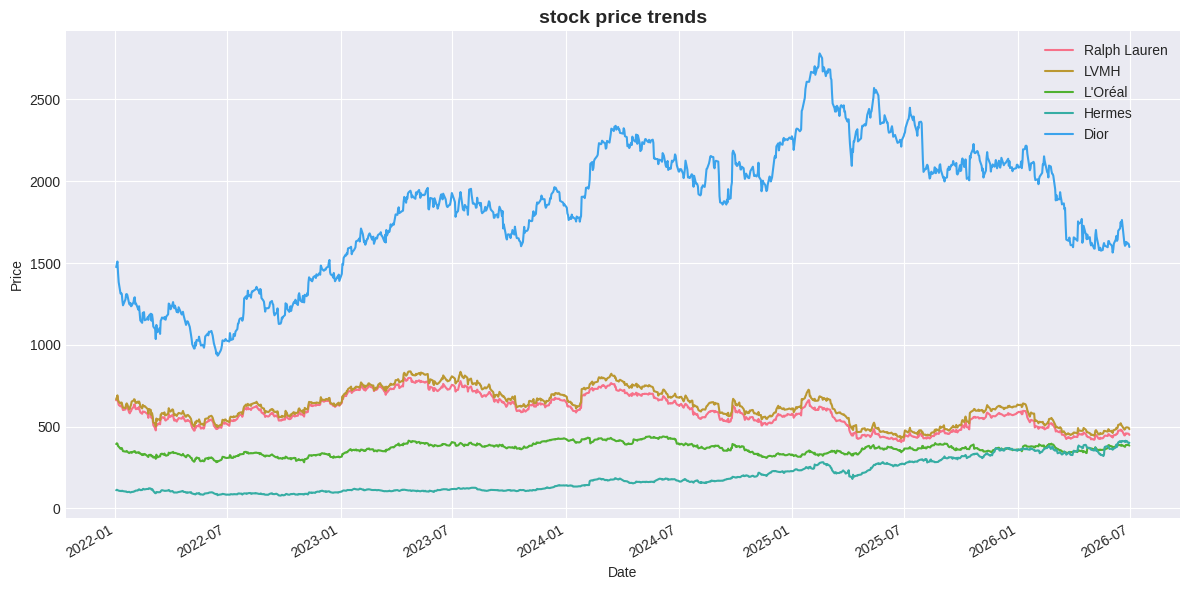

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
data.plot(ax=ax)
ax.set_title("stock price trends", fontsize=14, fontweight='bold')
ax.set_ylabel("Price")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig('prices.png', dpi=150)
plt.show()

## 5. normalized return (rise in % from start)

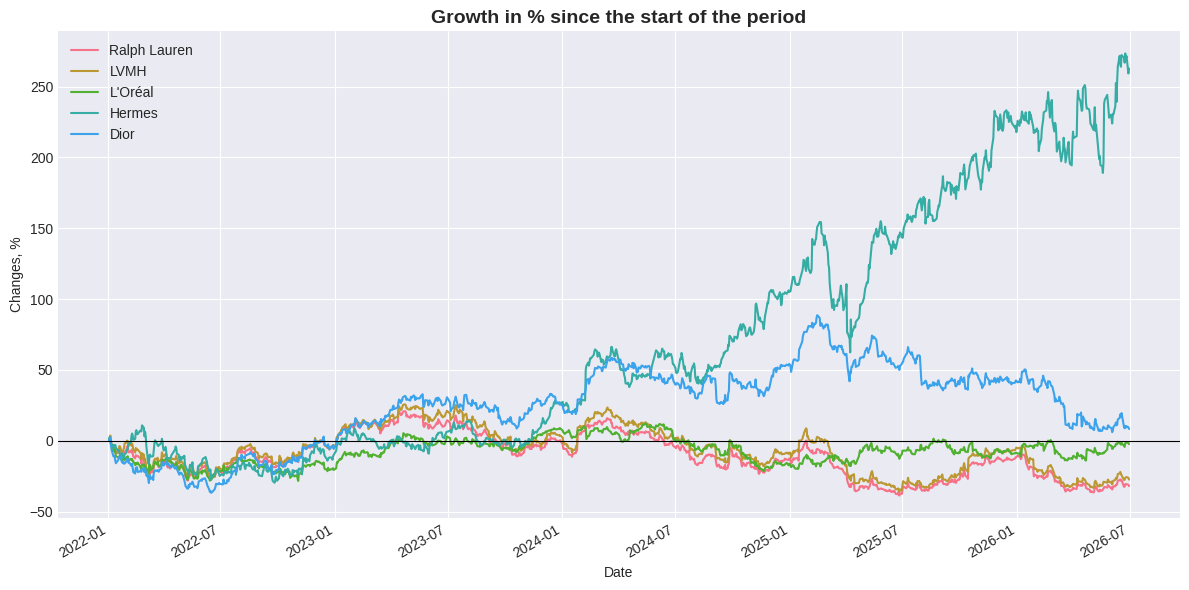

In [39]:
normalized = (data / data.iloc[0] - 1) * 100

fig, ax = plt.subplots(figsize=(12, 6))
normalized.plot(ax=ax)
ax.set_title("Growth in % since the start of the period", fontsize=14, fontweight='bold')
ax.set_ylabel("Changes, %")
ax.set_xlabel("Date")
ax.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('normalized_returns.png', dpi=150)
plt.show()

## 6. Annual return and volatility (Risk)



In [40]:
daily_returns = data.pct_change().dropna()

annual_return = daily_returns.mean() * 252 * 100
annual_volatility = daily_returns.std() * np.sqrt(252) * 100

summary = pd.DataFrame({
    "Annual return(%)": annual_return.round(2),
    "Annual volatility / risk (%)": annual_volatility.round(2)
})
summary["Return / risk"] = (summary["Annual return(%)"] / summary["Annual volatility / risk (%)"]).round(2)
summary.sort_values("Return / risk", ascending=False)

,Annual return(%),Annual volatility / risk (%),Return / risk
Hermes,36.15,37.42,0.97
Dior,6.19,29.60,0.21
L'Oréal,2.67,25.40,0.11
LVMH,-2.53,30.81,-0.08
Ralph Lauren,-4.18,30.28,-0.14


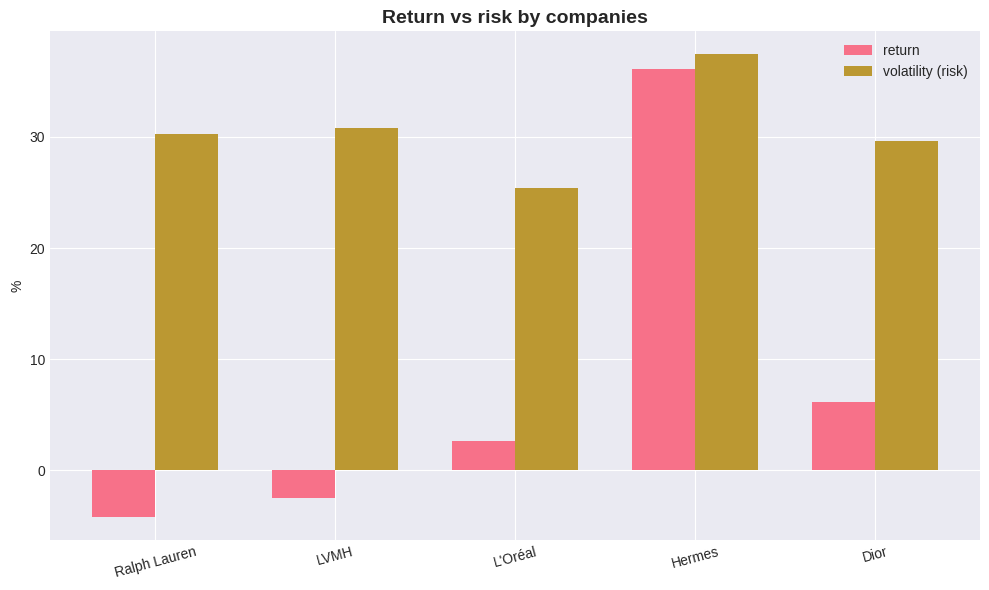

In [41]:
annual_return = daily_returns.mean() * 252 * 100
annual_volatility = daily_returns.std() * np.sqrt(252) * 100

summary = pd.DataFrame({
    "annual return(%)": annual_return.round(2),
    "annual return / risk (%)": annual_volatility.round(2)
})
summary["return / risk"] = (summary["annual return(%)"] / summary["annual return / risk (%)"]).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(names))
width = 0.35
ax.bar(x - width/2, summary["annual return(%)"], width, label="return")
ax.bar(x + width/2, summary["annual return / risk (%)"], width, label="volatility (risk)")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("%")
ax.set_title("Return vs risk by companies", fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('return_vs_risk.png', dpi=150)
plt.show()

## 7. Value at Risk (VaR)

In [42]:
var_95 = daily_returns.quantile(1 - confidence_level) * 100

# Rename columns to match expected casing and full name from j9hvWxVtqUIe
summary.rename(columns={
    "annual return(%)": "Annual return(%)",
    "annual return / risk (%)": "Annual volatility / risk (%)"
}, inplace=True)

summary["VaR 95% (daily, %)"] = var_95.round(2)
print("Value at Risk — interpretation:")
print("For example, VaR = -3% means: with 95% probability, the daily loss won't exceed 3% of the position's value.\n")
summary[["Annual return(%)", "Annual volatility / risk (%)", "VaR 95% (daily, %)"]]

Value at Risk — interpretation:
For example, VaR = -3% means: with 95% probability, the daily loss won't exceed 3% of the position's value.



,Annual return(%),Annual volatility / risk (%),"VaR 95% (daily, %)"
Ralph Lauren,-4.18,30.28,-3.00
LVMH,-2.53,30.81,-2.96
L'Oréal,2.67,25.40,-2.33
Hermes,36.15,37.42,-3.35
Dior,6.19,29.60,-2.90


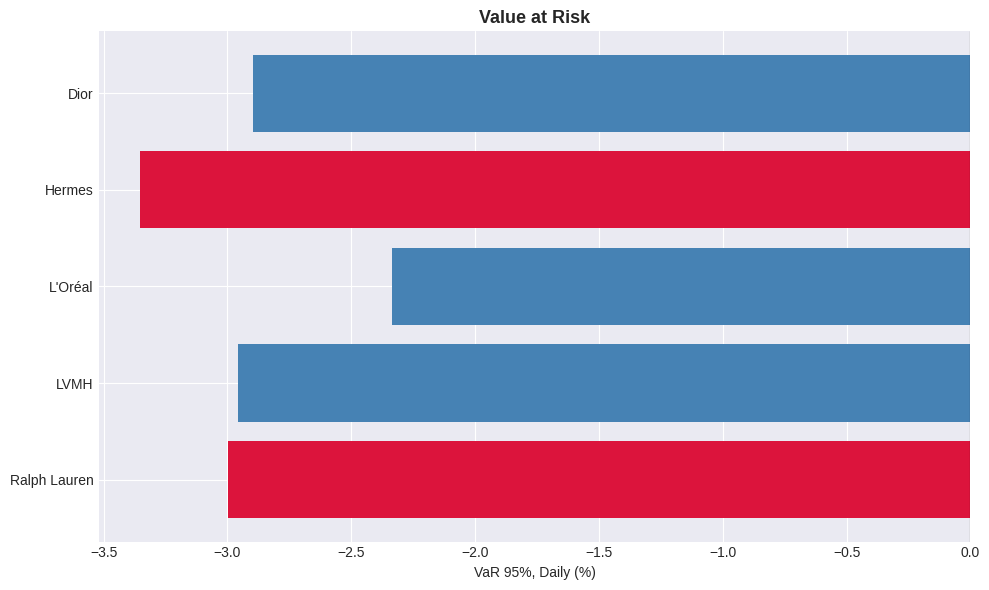

In [43]:
confidence_level = 0.95
var_95 = daily_returns.quantile(1 - confidence_level) * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['crimson' if v < var_95.median() else 'steelblue' for v in var_95]
ax.barh(names, var_95, color=colors)
ax.set_xlabel("VaR 95%, Daily (%)")
ax.set_title("Value at Risk", fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('var_chart.png', dpi=150)
plt.show()

## 8. Correlation of daily returns between companies


/tmp/ipykernel_1205/991146845.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)["Close"]
[*********************100%***********************]  5 of 5 completed


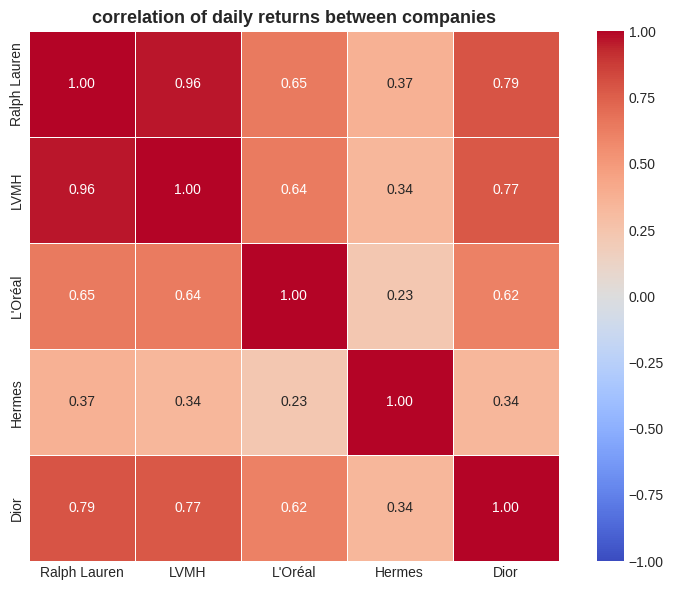

In [45]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tickers = ["Rl", "MC.PA", "OR.PA", "RMS.PA", "CDI.PA"]
names = ["Ralph Lauren", "LVMH", "L'Oréal", "Hermes", "Dior"]
start_date = "2022-01-01"
end_date = "2026-07-01"

data = yf.download(tickers, start=start_date, end=end_date)["Close"]
data.columns = names
data = data.dropna()

daily_returns = data.pct_change().dropna()

corr_matrix = daily_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("correlation of daily returns between companies", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150)
plt.show()

## 9. Final summary table


In [46]:
final_table = summary.copy()
final_table

,Annual return(%),Annual volatility / risk (%),return / risk,"VaR 95% (daily, %)"
Ralph Lauren,-4.18,30.28,-0.14,-3.00
LVMH,-2.53,30.81,-0.08,-2.96
L'Oréal,2.67,25.40,0.11,-2.33
Hermes,36.15,37.42,0.97,-3.35
Dior,6.19,29.60,0.21,-2.90


## 10. Overview

Overall, L'Oréal showed the best VaR (-2.33%) among the analyzed companies, while Hermès had the worst VaR (-3.35%). Hermès was also the most volatile stock (37.42%) and delivered the highest annual return (36.15%). This volatility was largely driven by geopolitical tensions in the Middle East, further compounded by weaker demand in China during Q1 2026.
The pair LVMH and Ralph Lauren showed the highest correlation (0.96), making it a riskier combination for a portfolio, as the two stocks move almost in sync — if one falls, the other is very likely to fall with it. In contrast, the pair Hermès and L'Oréal showed a low correlation (0.23), meaning they move independently of each other: if one declines, the other may behave completely differently. This makes them a stronger pairing for a portfolio, as it carries less risk than a combination like LVMH and Ralph Lauren.
If I had $10,000 to allocate across this portfolio, I would distribute it as follows:
$3,500 in L'Oréal and $3,500 in Hermès. This pair's low correlation makes it well-suited for a portfolio, as it reduces overall risk. L'Oréal also stands out for its favorable VaR, making it the less risky holding, while Hermès offers strong annual returns (37.45%) that justify its higher risk.
$1,000 in Dior, which also shows low correlation with the first pair and a reasonably good VaR (-2.90%).
The remaining $2,000 I would keep uninvested for now, reserved for other stocks not covered in this analysis — likely allocating it later to a higher-return opportunity.

---


